In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from IPython.display import display as disp
import preprocessing
import lstm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import mlflow
import subprocess
import optuna

The dataset selected is the NASA C-MAPSS (Commercial Modular Aero-Propulsion System Simulation). It is a set of simulated multivariate time-series data from turbofan engines used to develop algorithms for predicting Remaining Useful Life (RUL). The dataset acts as a benchmark for predictive maintenance and prognostics, featuring simulated sensor noise and degradation from multiple engine components, such as fans, compressors, and turbines. From the readme.txt for the dataset, we have the following:

Data Set: FD001
Train trjectories: 100
Test trajectories: 100
Conditions: ONE (Sea Level)
Fault Modes: ONE (HPC Degradation)

Data Set: FD002
Train trjectories: 260
Test trajectories: 259
Conditions: SIX
Fault Modes: ONE (HPC Degradation)

Data Set: FD003
Train trjectories: 100
Test trajectories: 100
Conditions: ONE (Sea Level)
Fault Modes: TWO (HPC Degradation, Fan Degradation)

Data Set: FD004
Train trjectories: 248
Test trajectories: 249
Conditions: SIX
Fault Modes: TWO (HPC Degradation, Fan Degradation)

The engine is operating normally at the start of each time series, and develops a fault at some point during the series. In the training set, the fault grows in magnitude until system failure. In the test set, the time series ends some time prior to system failure. The objective of the competition is to predict the number of remaining operational cycles before failure in the test set, i.e., the number of operational cycles after the last cycle that the engine will continue to operate. Also provided a vector of true Remaining Useful Life (RUL) values for the test data.

The data are provided as a zip-compressed text file with 26 columns of numbers, separated by spaces. Each row is a snapshot of data taken during a single operational cycle, each column is a different variable. The columns correspond to:<br>
1)	unit number<br>
2)	time, in cycles<br>
3)	operational setting 1<br>
4)	operational setting 2<br>
5)	operational setting 3<br>
6)	sensor measurement  1<br>
7)	sensor measurement  2<br>
...<br>
26)	sensor measurement  21<br>

# 1. Data Exploration



To become familiar with the dataset, we will visualize it from several angles using matplotlib and seaborn.





In [6]:
data_dict = preprocessing.parse_data()



Below are the summary statistics for each of the operating conditions mentioned in the readme file.



In [7]:
for i in data_dict:
    print(f"Preview of data for FD00{str(i)}")
    disp(data_dict[i].describe())
    print("\n")

Preview of data for FD001


,Unit Number,"Time, In Cycles",Setting 1,Setting 2,Setting 3,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,...,Sensor 12,Sensor 13,Sensor 14,Sensor 15,Sensor 16,Sensor 17,Sensor 18,Sensor 19,Sensor 20,Sensor 21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,5.329200e-15,...,0.737553,0.071919,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400




Preview of data for FD002


,Unit Number,"Time, In Cycles",Setting 1,Setting 2,Setting 3,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,...,Sensor 12,Sensor 13,Sensor 14,Sensor 15,Sensor 16,Sensor 17,Sensor 18,Sensor 19,Sensor 20,Sensor 21
count,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,...,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000
mean,131.082981,109.154746,23.998407,0.572056,94.046020,472.910207,579.672399,1419.971013,1205.442024,8.031986,...,266.069034,2334.557253,8066.597682,9.329654,0.023326,348.309511,2228.806358,97.756838,20.789296,12.473423
std,74.463862,69.180569,14.747376,0.310016,14.237735,26.389707,37.289399,105.946341,119.123428,3.613839,...,137.659507,128.068271,84.837950,0.749335,0.004711,27.754515,145.327980,5.364067,9.869331,5.921615
min,1.000000,1.000000,0.000000,0.000000,60.000000,445.000000,535.530000,1243.730000,1023.770000,3.910000,...,129.120000,2027.610000,7848.360000,8.335700,0.020000,303.000000,1915.000000,84.930000,10.180000,6.010500
25%,68.000000,52.000000,10.004600,0.250700,100.000000,445.000000,549.570000,1352.760000,1123.655000,3.910000,...,131.520000,2387.900000,8062.140000,8.677800,0.020000,331.000000,2212.000000,100.000000,10.910000,6.546300
50%,131.000000,104.000000,25.001300,0.700000,100.000000,462.540000,555.980000,1369.180000,1138.890000,7.050000,...,183.200000,2388.080000,8082.540000,9.310900,0.020000,335.000000,2223.000000,100.000000,14.880000,8.929200
75%,195.000000,157.000000,41.998000,0.840000,100.000000,491.190000,607.340000,1499.370000,1306.850000,10.520000,...,371.260000,2388.170000,8127.195000,9.386900,0.030000,369.000000,2324.000000,100.000000,28.470000,17.083200
max,260.000000,378.000000,42.008000,0.842000,100.000000,518.670000,644.520000,1612.880000,1439.230000,14.620000,...,523.370000,2390.480000,8268.500000,11.066900,0.030000,399.000000,2388.000000,100.000000,39.340000,23.590100




Preview of data for FD003


,Unit Number,"Time, In Cycles",Setting 1,Setting 2,Setting 3,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,...,Sensor 12,Sensor 13,Sensor 14,Sensor 15,Sensor 16,Sensor 17,Sensor 18,Sensor 19,Sensor 20,Sensor 21
count,24720.000000,24720.000000,24720.000000,24720.000000,24720.0,24720.00,24720.000000,24720.000000,24720.000000,2.472000e+04,...,24720.000000,24720.000000,24720.000000,24720.000000,2.472000e+04,24720.000000,24720.0,24720.0,24720.000000,24720.000000
mean,48.631877,139.077063,-0.000024,0.000005,100.0,518.67,642.457858,1588.079175,1404.471212,1.462000e+01,...,523.050873,2388.071643,8144.202916,8.396176,3.000000e-02,392.566545,2388.0,100.0,38.988552,23.393024
std,29.348985,98.846675,0.002194,0.000294,0.0,0.00,0.523031,6.810418,9.773178,3.552786e-15,...,3.255314,0.158121,16.504118,0.060512,6.939034e-18,1.761459,0.0,0.0,0.248865,0.149234
min,1.000000,1.000000,-0.008600,-0.000600,100.0,518.67,640.840000,1564.300000,1377.060000,1.462000e+01,...,517.770000,2386.930000,8099.680000,8.156300,3.000000e-02,388.000000,2388.0,100.0,38.170000,22.872600
25%,23.000000,62.000000,-0.001500,-0.000200,100.0,518.67,642.080000,1583.280000,1397.187500,1.462000e+01,...,521.150000,2388.010000,8134.510000,8.360600,3.000000e-02,391.000000,2388.0,100.0,38.830000,23.296200
50%,47.000000,124.000000,-0.000000,-0.000000,100.0,518.67,642.400000,1587.520000,1402.910000,1.462000e+01,...,521.980000,2388.070000,8141.200000,8.398300,3.000000e-02,392.000000,2388.0,100.0,38.990000,23.391600
75%,74.000000,191.000000,0.001500,0.000300,100.0,518.67,642.790000,1592.412500,1410.600000,1.462000e+01,...,523.840000,2388.140000,8149.230000,8.437000,3.000000e-02,394.000000,2388.0,100.0,39.140000,23.483300
max,100.000000,525.000000,0.008600,0.000700,100.0,518.67,645.110000,1615.390000,1441.160000,1.462000e+01,...,537.400000,2388.610000,8290.550000,8.570500,3.000000e-02,399.000000,2388.0,100.0,39.850000,23.950500




Preview of data for FD004


,Unit Number,"Time, In Cycles",Setting 1,Setting 2,Setting 3,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,...,Sensor 12,Sensor 13,Sensor 14,Sensor 15,Sensor 16,Sensor 17,Sensor 18,Sensor 19,Sensor 20,Sensor 21
count,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,...,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000
mean,124.325181,134.311417,23.999823,0.571347,94.031576,472.882435,579.420056,1417.896600,1201.915359,8.031626,...,266.735665,2334.427590,8067.811812,9.285604,0.023252,347.760029,2228.613283,97.751396,20.864333,12.518995
std,71.995350,89.783389,14.780722,0.310703,14.251954,26.436832,37.342647,106.167598,119.327591,3.622872,...,138.479109,128.197859,85.670543,0.750374,0.004685,27.808283,145.472491,5.369424,9.936396,5.962697
min,1.000000,1.000000,0.000000,0.000000,60.000000,445.000000,535.480000,1242.670000,1024.420000,3.910000,...,128.310000,2027.570000,7845.780000,8.175700,0.020000,302.000000,1915.000000,84.930000,10.160000,6.084300
25%,60.000000,62.000000,10.004600,0.250700,100.000000,445.000000,549.330000,1350.550000,1119.490000,3.910000,...,134.520000,2387.910000,8062.630000,8.648000,0.020000,330.000000,2212.000000,100.000000,10.940000,6.566100
50%,126.000000,123.000000,25.001400,0.700000,100.000000,462.540000,555.740000,1367.680000,1136.920000,7.050000,...,183.450000,2388.060000,8083.810000,9.255600,0.020000,334.000000,2223.000000,100.000000,14.930000,8.960100
75%,185.000000,191.000000,41.998100,0.840000,100.000000,491.190000,607.070000,1497.420000,1302.620000,10.520000,...,371.400000,2388.170000,8128.350000,9.365800,0.030000,368.000000,2324.000000,100.000000,28.560000,17.135500
max,249.000000,543.000000,42.008000,0.842000,100.000000,518.670000,644.420000,1613.000000,1440.770000,14.620000,...,537.490000,2390.490000,8261.650000,11.066300,0.030000,399.000000,2388.000000,100.000000,39.890000,23.885200


Those summary statistics show that there are some settings/sensors that have a standard deviation of zero. Those can potentially be removed at the data preprocessing stage. Also worth noting is the difference in scale of the many sensors. For instance, sensor 21 has a maximum value ~20, and sensor 3 has maximum values exceeding 1000.



---
It may also be useful to compute when each engine failed to get an idea of the typical unit life cycle.


In [8]:
cycles_to_fail = {}
for i in data_dict:
    df = data_dict[i]
    ctf = df.groupby("Unit Number")["Time, In Cycles"].max().reset_index()
    cycles_to_fail[i] = ctf

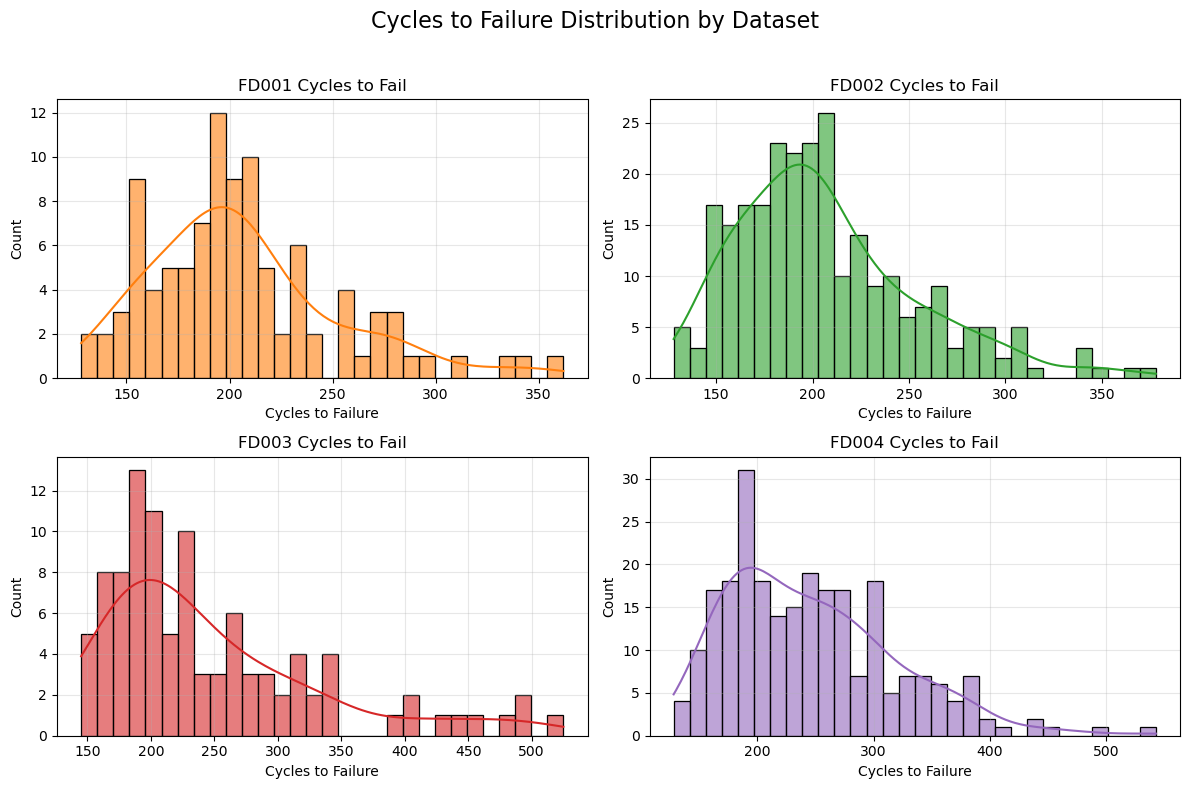

In [9]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharey=False)
for i in range(1, 5):
    ax = axs[(i - 1) // 2][(i - 1) % 2]
    sns.histplot(
        cycles_to_fail[i]["Time, In Cycles"],
        ax=ax,
        kde=True,
        bins=30,
        color=f"C{i}",
        edgecolor="black",
        alpha=0.6,
    )
    ax.set_title(f"FD00{i} Cycles to Fail")
    ax.set_xlabel("Cycles to Failure")
    ax.set_ylabel("Count")
    ax.grid(alpha=0.3)

fig.suptitle("Cycles to Failure Distribution by Dataset", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

The data is very high dimensional, so it is difficult to view everything at once. However, it may be useful to view a subset of the time series. From each dataset, we'll choose the unit with the max, min, and medium cycles to failure and plot a few axes of the multidimensional time series.

In [10]:
sample_units = {}
for i in cycles_to_fail:
    ctf = cycles_to_fail[i]
    sample_units[i] = (ctf.loc[ctf["Time, In Cycles"] == ctf["Time, In Cycles"].max(), "Unit Number"].values[0],
                    ctf.loc[ctf["Time, In Cycles"] == ctf["Time, In Cycles"].min(), "Unit Number"].values[0],
                    ctf.loc[ctf["Time, In Cycles"] == np.floor(ctf["Time, In Cycles"].median()), "Unit Number"].values[0])
for i in sample_units:
    print(f"FD00{i} Sample Units (max,min,median): {sample_units[i]}")

FD001 Sample Units (max,min,median): (np.int64(69), np.int64(39), np.int64(26))
FD002 Sample Units (max,min,median): (np.int64(112), np.int64(244), np.int64(9))
FD003 Sample Units (max,min,median): (np.int64(55), np.int64(99), np.int64(21))
FD004 Sample Units (max,min,median): (np.int64(118), np.int64(214), np.int64(147))


For the min/max/median in each dataset, we'll plot the sensors that have the highest variance to get an idea of how things are changing with time

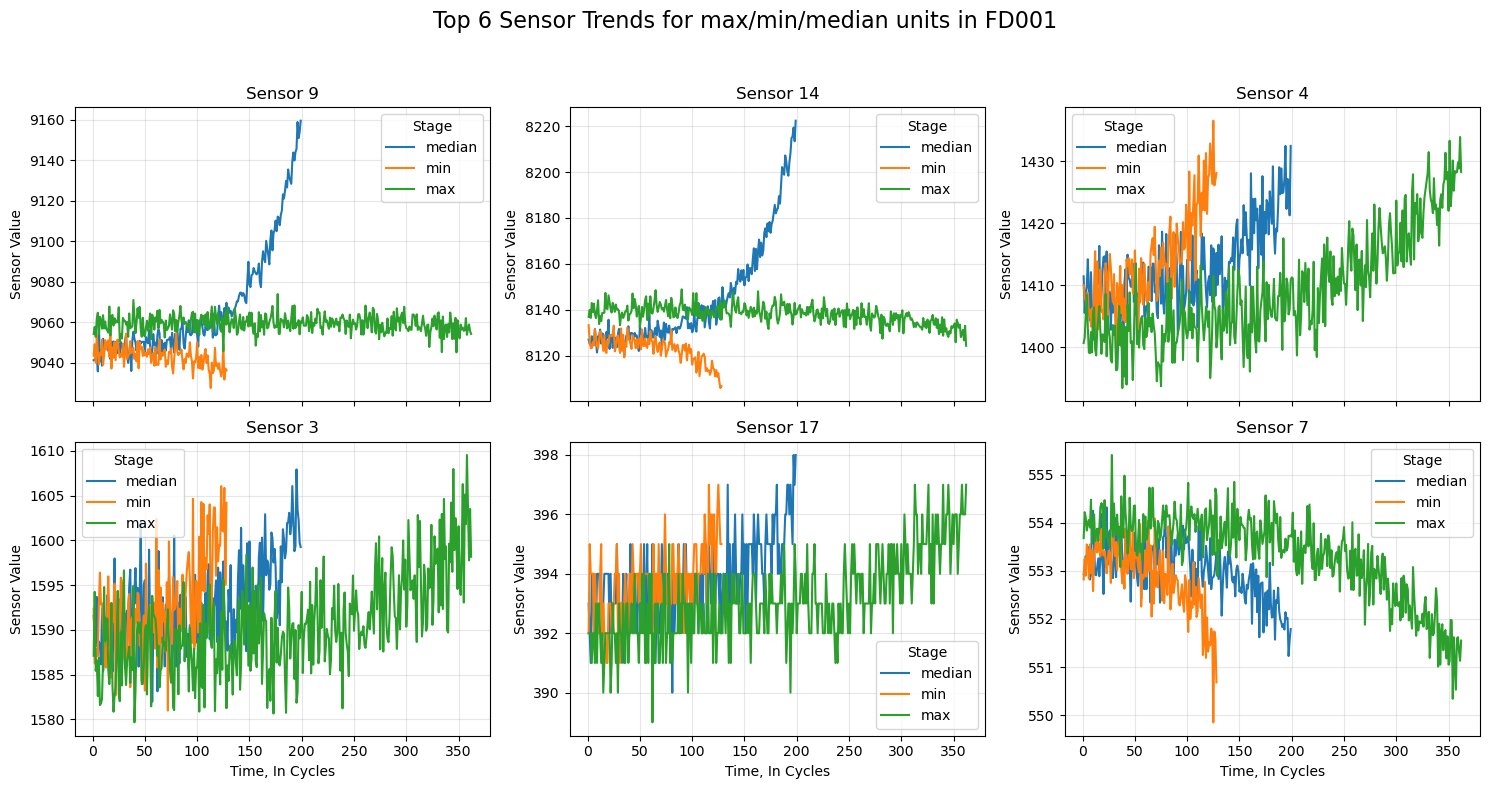

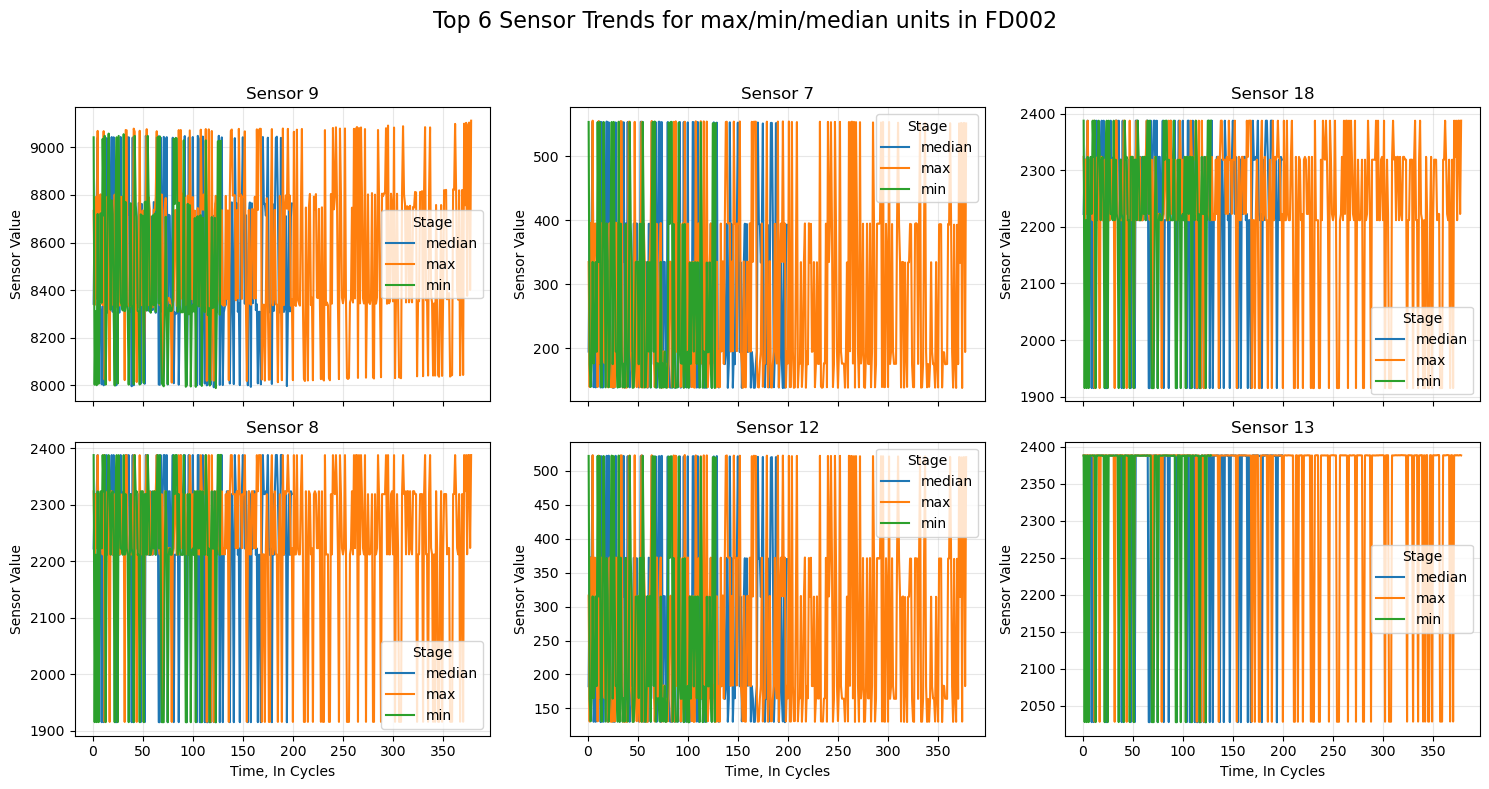

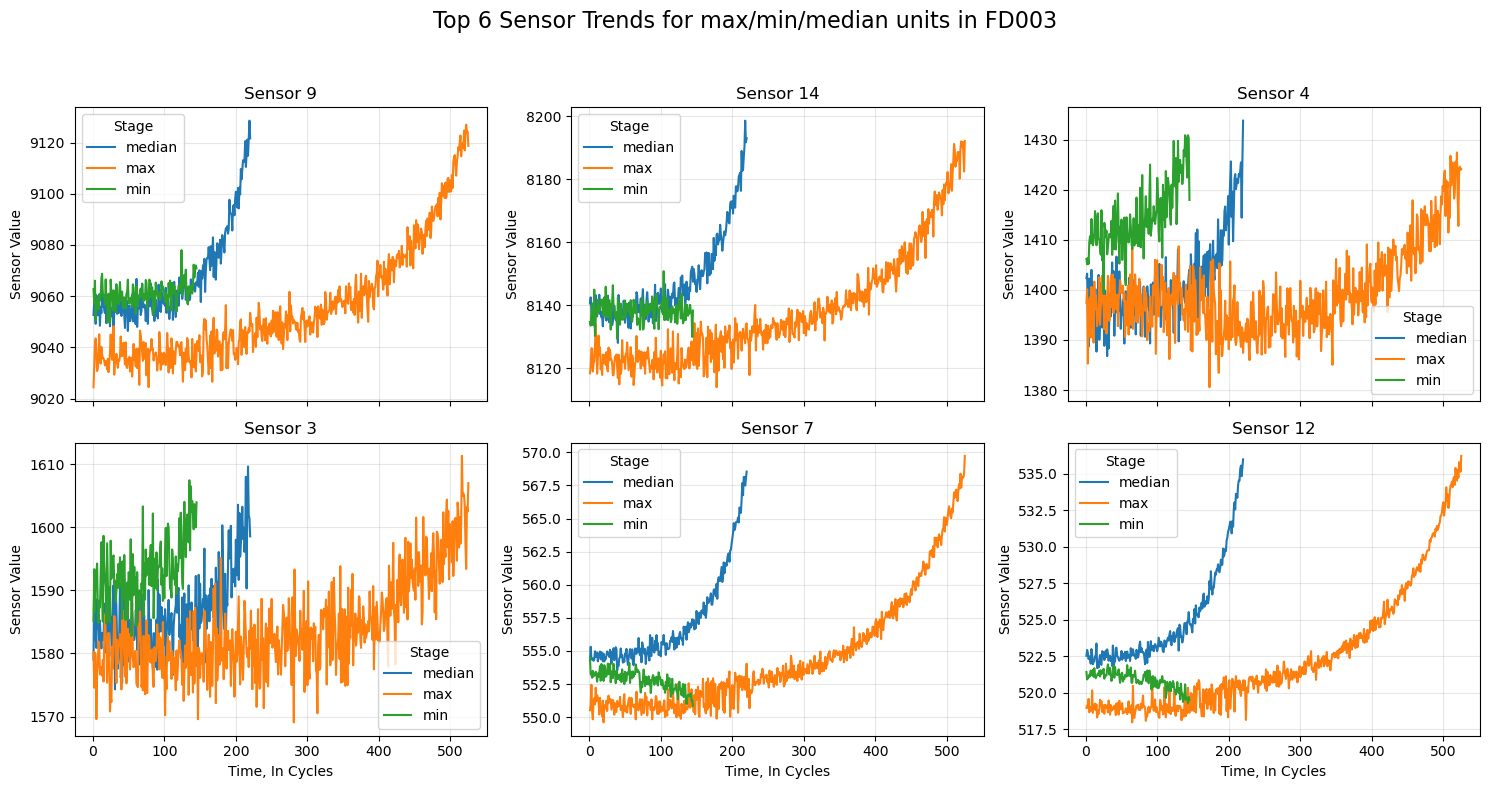

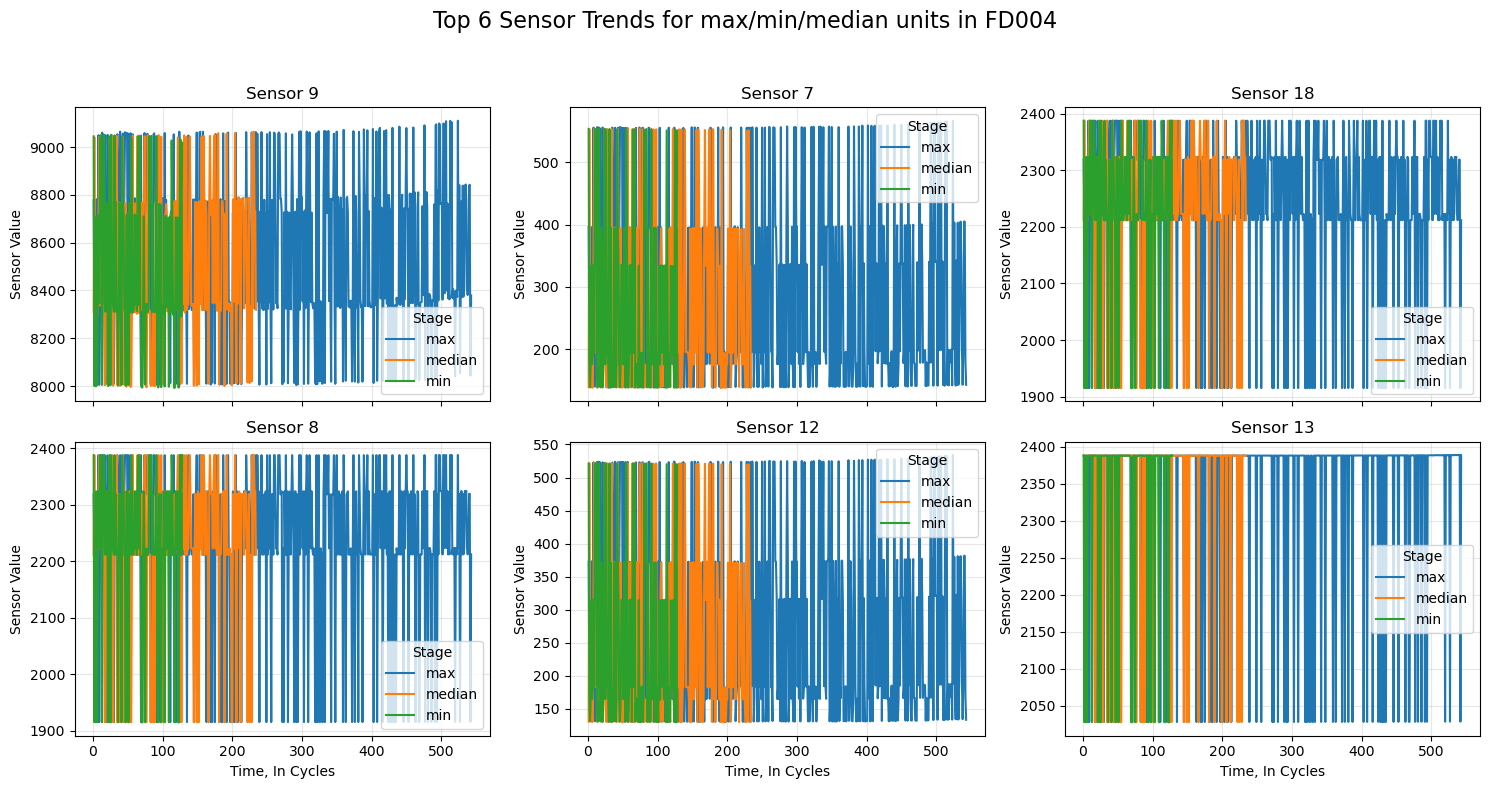

In [11]:
for i, units in sample_units.items():
    df = data_dict[i]
    selected_df = df[df["Unit Number"].isin(units)].copy() #slicing the dataframe to choose only max, min, and median units found in previous cell
    selected_df["Stage"] = selected_df["Unit Number"].map({
        units[0]: "max",
        units[1]: "min",
        units[2]: "median",
    }) # mapping the unit numbers to their respective stages for color coding the plots - "Stage" column determines color on the line plots

    sensor_cols = [col for col in df.columns if col.startswith("Sensor")]
    top_sensors = (
        df[sensor_cols].var().sort_values(ascending=False).head(6).index.tolist()
    ) #selecting the sensors that had the highest variance across the the max, min, and median units for each dataset

    fig, axs = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
    for j, col in enumerate(top_sensors):
        ax = axs[j // 3][j % 3]
        sns.lineplot(
            data=selected_df,
            x="Time, In Cycles",
            y=col,
            hue="Stage",
            ax=ax,
            palette="tab10",
        )
        ax.set_title(col)
        ax.set_xlabel("Time, In Cycles")
        ax.set_ylabel("Sensor Value")
        ax.grid(alpha=0.3)

    fig.suptitle(
        f"Top 6 Sensor Trends for max/min/median units in FD00{i}",
        fontsize=16,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

### Some key takeaways here:
1. The time series in FD001 AND FD003 have an exponential-looking trend, and FD002 and FD004 do not appear to have a trend
2. All the sensors are on a different scale, so it will be necessary to either scale or normalize the data
3. Sensors 9 and 7 appear appear in the "top 6" sensors for each dataset, so they could be imporant to pay attention to


---
The readme mentioned that each dataset is built from engines at different and varying operating conditions. Thus, the time series for Settings 1-3 should also be visualized


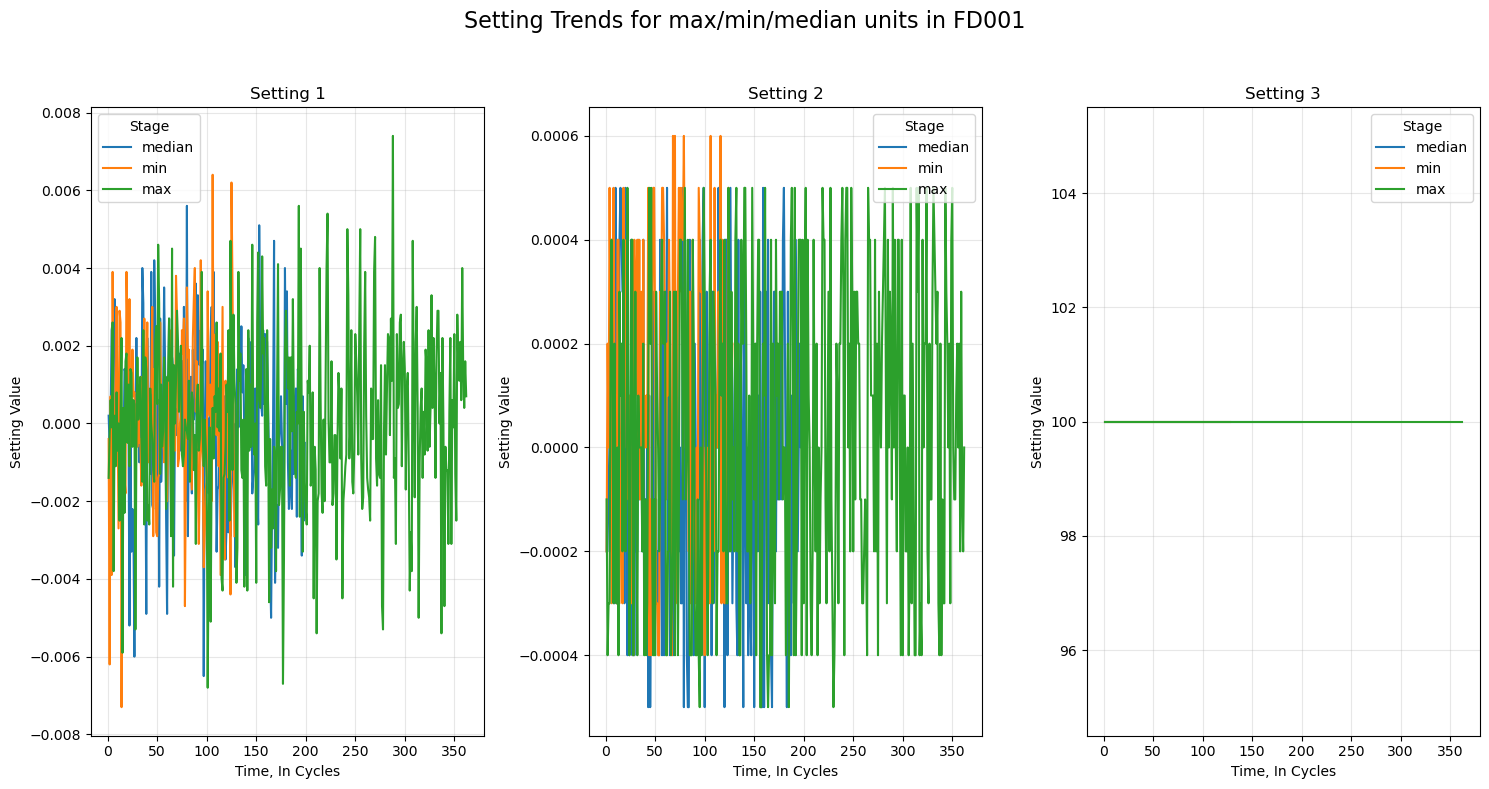

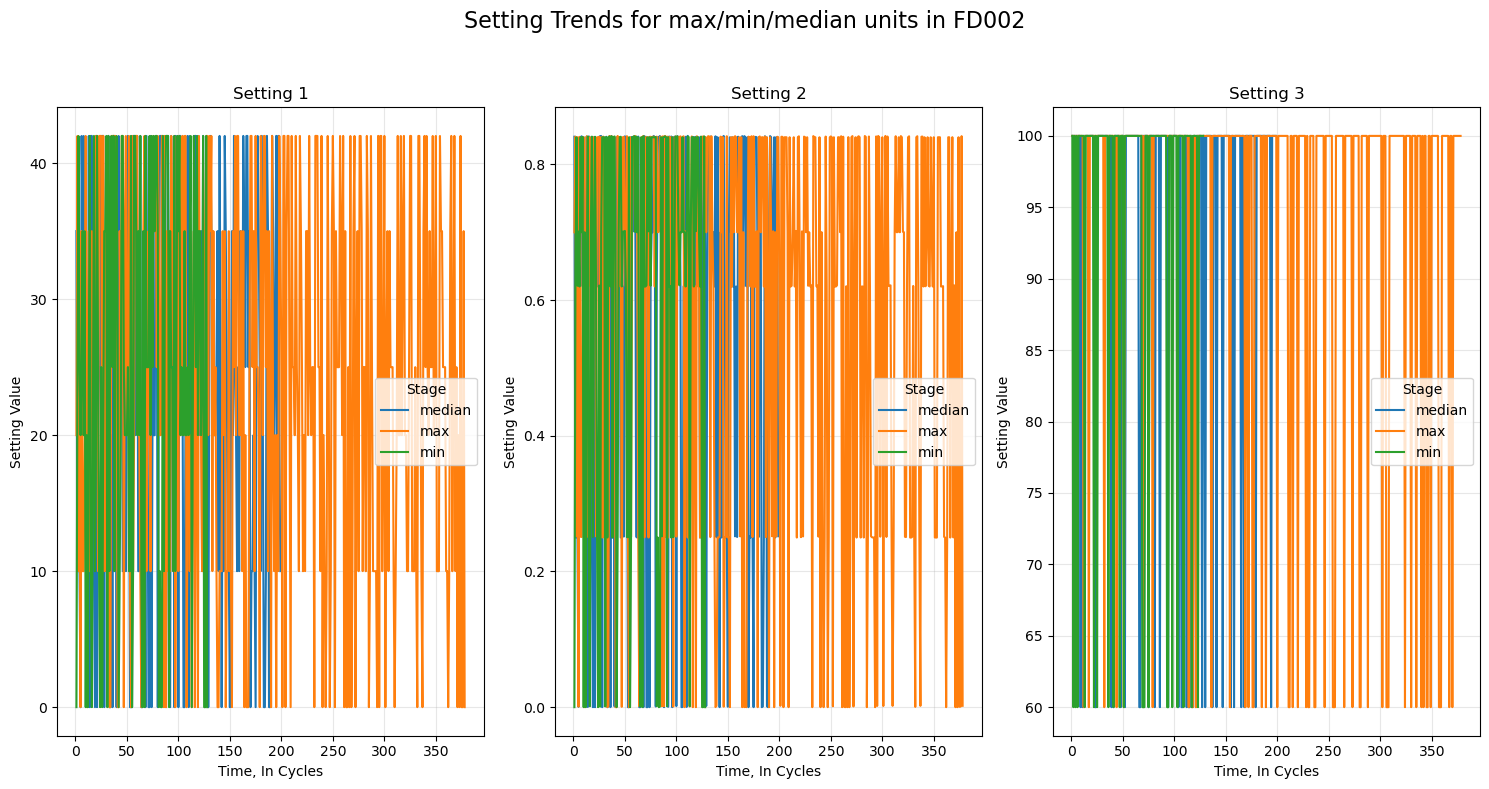

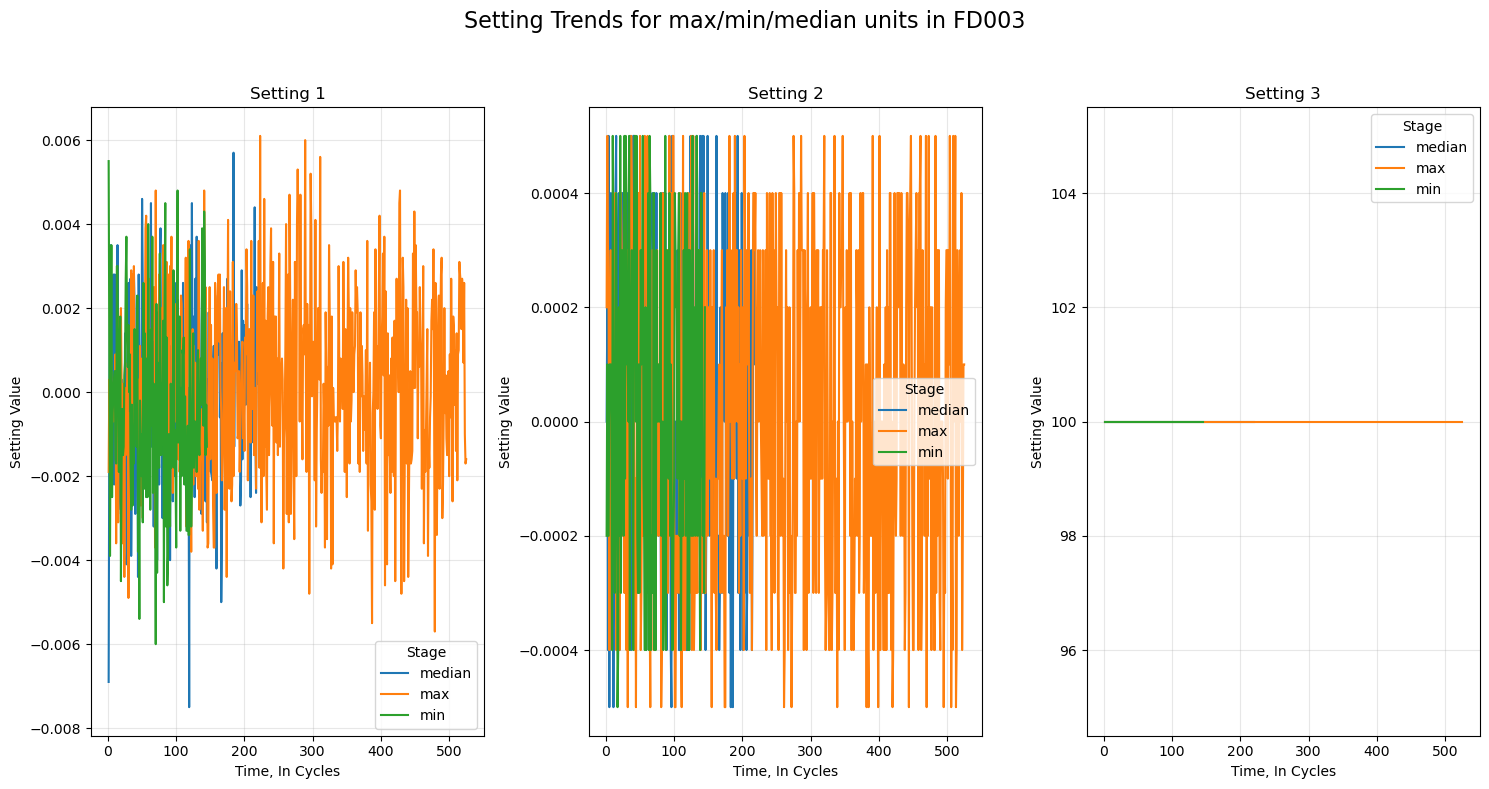

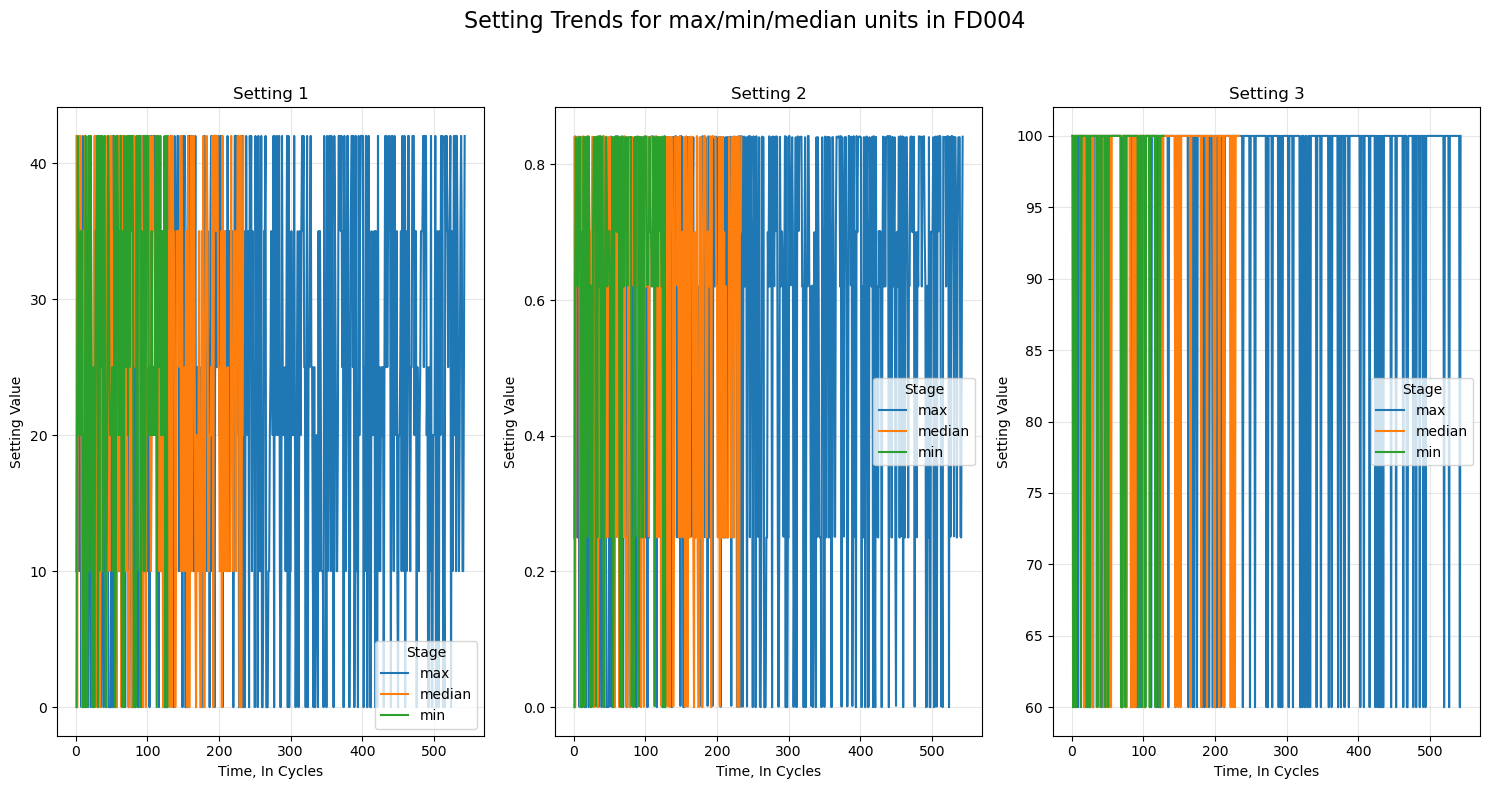

In [12]:
nrow = 1
for i, units in sample_units.items():
    df = data_dict[i]
    selected_df = df[df["Unit Number"].isin(units)].copy() #slicing the dataframe to choose only max, min, and median units found in previous cell
    selected_df["Stage"] = selected_df["Unit Number"].map({
        units[0]: "max",
        units[1]: "min",
        units[2]: "median",
    }) # mapping the unit numbers to their respective stages for color coding the plots - "Stage" column determines color on the line plots

    setting_cols = [col for col in df.columns if col.startswith("Setting")]
    fig, axs = plt.subplots(nrows=nrow, ncols=len(setting_cols), figsize=(15, 8), sharex=True)
    for j, col in enumerate(setting_cols):
        ax = axs[j]
        sns.lineplot(
            data=selected_df,
            x="Time, In Cycles",
            y=col,
            hue="Stage",
            ax=ax,
            palette="tab10",
        )
        ax.set_title(col)
        ax.set_xlabel("Time, In Cycles")
        ax.set_ylabel("Setting Value")
        ax.grid(alpha=0.3)

    fig.suptitle(
        f"Setting Trends for max/min/median units in FD00{i}",
        fontsize=16,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

### Observations from the operational settings:
1. FD001 and FD003 have a constant Setting 3, but this was specified in the readme, so not a bad thing
2. Compared to the variation in FD002 and FD004, Settings 1 and 2 have negligible change for datasets FD001 and FD003

# 2. Data Preprocessing + Feature Engineering

The objective with this dataset is to predict an engine's remaining useful life (RUL). However, these values are not explicitly given. Instead, they are computed as part of the pipeline

### Pipeline A is tailored to the  xgBoost and Random Forest models. It consists of the following data transformations:
1. Filtering Based on Coefficient of Variation<br>
The dataset consists of a 24-dimensional time series - 21 sensors and 3 operational settings. To reduce dimensionality, the sensors were filtered according to:<br>
$\begin{align}
          CV = |\frac{\sigma}{\mu}| > \tau
\end{align}
$<br>
If $CV>\tau$, the sensor time series is kept. Otherwise, the sensor is removed to reduce dataset dimensionality. We are using $\tau = 0.05$ in this notebook.
2. The RUL is computed by taking the difference between the final time-step $x_f$ and the current time step $x_t$. <br>
$RUL=x_f - x_t$

3. Three lag features are computed<br>
$L_1 = x_{t-1}$<br>
$L_2 = x_{t-2}$<br>
$L_3 = x_{t-3}$<br>
This operation is a completed by calling *df.shift(lag)*
4. Window features are computed with a window size of 5. This is a high risk for data leakage. To prevent leaks, *df.shift(1)* is called to prevent training on future data. Then, *df.rolling()* is used to compute the window features. Only the mean and standard deviation are computed as window features.
5. Standardization on all sensor data
6. The RUL is capped at 125. An image of the Time in Cycles is given below. It shows that essentially all units survive a minimum number of cycles (in this case, ~125). There is no need to distinguish between an engine that will survive 300 cycles and an engine that will survive 125+. They are both healthy engines. Thus, the RUL is capped at 125 in Pipeline A.
<br>

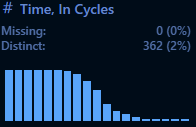

Notes:
- Missing values resulting from the windowing and lag features were dropped by row. Since we have several engines to test, and most of them have >100 points, we can afford to drop the few na rows.
- To avoid data leakage between units, *df.groupby("Unit Number")* was called before feature engineering.

In [13]:
# pipeline A data preprocessing
pipe_A = preprocessing.pipeline_A(data_dict)

# ref datasets allows lstm to split up data for different engines
train_ref = pd.concat(pipe_A["train"].values(), ignore_index=True)
val_ref = pd.concat(pipe_A["val"].values(), ignore_index=True)

xA_train, yA_train = preprocessing.target_feature_split(train_ref)
xA_val, yA_val = preprocessing.target_feature_split(val_ref)

x_scaler = StandardScaler()
y_scaler = StandardScaler()
xA_train_std = x_scaler.fit_transform(xA_train)
xA_val_std = x_scaler.transform(xA_val)
yA_train_std = y_scaler.fit_transform(yA_train.values.reshape(-1, 1)).flatten()
yA_val_std = y_scaler.transform(yA_val.values.reshape(-1, 1)).flatten()

### Pipeline B is tailored to Linear Regression. It is different from Pipeline A in the following ways:
1. It applies exponential smoothing
2. It does not filter based on CV
3. It uses MinMax scaling instead of standardization

In [14]:
# pipeline B data preprocessing
pipe_B = preprocessing.pipeline_B(data_dict)
train_ref_B = pd.concat(pipe_B["train"].values(), ignore_index=True)
val_ref_B = pd.concat(pipe_B["val"].values(), ignore_index=True)
xB_train, yB_train = preprocessing.target_feature_split(train_ref_B)
xB_val, yB_val = preprocessing.target_feature_split(val_ref_B)
xB_scaler = MinMaxScaler()
yB_scaler = MinMaxScaler()
xB_train_minMax = xB_scaler.fit_transform(xB_train)
xB_val_minMax = xB_scaler.transform(xB_val)
yB_train_minMax = yB_scaler.fit_transform(yB_train.values.reshape(-1, 1)).flatten()
yB_val_minMax = yB_scaler.transform(yB_val.values.reshape(-1, 1)).flatten()

### Pipeline C Raw Data without any preprocessing

In [15]:
# pipeline C preprocessing
pipe_C_split = preprocessing.train_val_split(data_dict.copy(), test_size=0.3)
train_ref_C = pd.concat(pipe_C_split["train"].values(), ignore_index=True)
val_ref_C = pd.concat(pipe_C_split["val"].values(), ignore_index=True)

#train-validation feature matrix and target vector
xC_train, yC_train = preprocessing.target_feature_split(train_ref_C)
xC_val, yC_val = preprocessing.target_feature_split(val_ref_C)
xC_train_raw = xC_train.values
xC_val_raw = xC_val.values
yC_train_raw = yC_train.values.reshape(-1, 1).flatten()
yC_val_raw = yC_val.values.reshape(-1, 1).flatten()

### Scaling Technique

With time series data, normalization or scaling presents a data leakage risk. If $x_t$ is scaled based on the entire time series, then, based on how amount of scaling, the model has information about $x_{t+1}$, $x_{t+2}$, and other future datapoints that it should not have access to. This presents a few options to handle scaling the data:
1. Do not normalize the data
2. Normalize the data using an expanding window
3. Normalize the data using information about its population mean and standard deviation<br>

In this notebook, we've opted to use option 3 because we have access to hundreds of turbine engines that are identical with the exception of when they develop a fault. Thus, scaling using the information about all engines removes the bias that would be introduced by normalizing on the full time series of a single engine. This approach comes with the added benefit of a constant normalization factor. With the expanding window, the mean and standard deviation would be changing with the window, so the values would be more difficult to interpret.

### Validation

For model validation, the approach we've used is to take a 70-30 split of engines from each dataset. So, for instance, FD001.txt has time series for 100 turbine units. We have randomly sampled 30 full time series from this dataset and allocated them for validation and hyperparameter tuning. The same 70-30 split was used across all datasets (i.e., FD001, FD002, etc.), and the data from each set was then flattened into a single dataframe.

### Importing the testing data and creating pipelines

In [16]:
from preprocessing import drop_low_cv_sensors, compute_RUL, compute_lags, compute_window_features, clip_RUL, train_val_split, exp_smooth

In [17]:
testing_data = {}
testing_labels = {}
for i in range(1,5):
    df = pd.read_csv(f"CMAPSSData/test_FD00{str(i)}.txt", sep=" ", header=None)
    lab = pd.read_csv(f"CMAPSSData/RUL_FD00{str(i)}.txt", sep=" ", header=None)
    df = df.drop(columns=[26, 27])  # Remove the last two empty columns
    df.columns = ["Unit Number", "Time, In Cycles", "Setting 1", "Setting 2", "Setting 3"] + [f"Sensor {i}" for i in range(1, 22)]
    testing_data[i] = df
    testing_labels[i] = lab.dropna(axis=1)

### Preparing the testing data for pipeline A

In [18]:
pipe_A_test, dropped_sensors = drop_low_cv_sensors(testing_data, threshold=0.05)
pipe_A_test = compute_RUL(pipe_A_test)
sensor_cols = [col for col in testing_data[1].columns.drop(dropped_sensors) if col.startswith("Sensor")]
pipe_A_test = compute_lags(pipe_A_test, sensor_cols=sensor_cols, lags=[1, 5, 20], drop_na = True)
pipe_A_test = compute_window_features(pipe_A_test, sensor_cols=sensor_cols, window_size=10, drop_na = True)
pipe_A_test = clip_RUL(pipe_A_test, max_RUL=125)

In [19]:
xa_test_list = []
ya_test_list = []

for k in pipe_A_test:
    df = pipe_A_test[k].copy()
    labels = testing_labels[k]

    # Create a mapping from 'Unit Number' to its ground truth RUL label
    # testing_labels[k] has index corresponding to engine (0 to N-1)
    # while Unit Numbers typically start at 1.
    unique_units = df["Unit Number"].unique()
    label_map = dict(zip(unique_units, labels.iloc[:, 0]))

    # The ground truth RUL for any row is:
    # (Current RUL relative to end of recording) + (RUL from testing_labels)
    df["True_RUL"] = df["Unit Number"].map(label_map) + df["RUL"]

    ya_test_list.append(df[["True_RUL"]])
    xa_test_list.append(df.drop(columns=["RUL", "True_RUL"]))

# Concatenate all datasets into final matrices
xa_test_unscaled = pd.concat(xa_test_list, ignore_index=True).drop(columns=["Unit Number", "Dataset"])
ya_test = pd.concat(ya_test_list, ignore_index=True).rename(columns={"True_RUL": "RUL"})

xa_test = x_scaler.transform(xa_test_unscaled)

split_test_A = train_val_split(pipe_A_test, test_size=0.3)
test_ref_A = pd.concat(pipe_A_test.values(), ignore_index=True)

print(f"Feature matrix shape: {xa_test.shape}")
print(f"Target vector shape: {ya_test.shape}")
print(f"ref shape: {test_ref_A.shape}")

Feature matrix shape: (89355, 118)
Target vector shape: (89355, 1)
ref shape: (89355, 121)


### Preparing the testing data for pipeline B

In [20]:
pipe_B_test = compute_RUL(testing_data)
pipe_B_test = preprocessing.exp_smooth(pipe_B_test)
sensor_cols = [col for col in testing_data[1].columns if col.startswith("Sensor")]
pipe_B_test = compute_lags(pipe_B_test, sensor_cols=sensor_cols, lags=[1, 5, 20], drop_na = True)
pipe_B_test = compute_window_features(pipe_B_test, sensor_cols=sensor_cols, window_size=10, drop_na = True)
pipe_B_test = clip_RUL(pipe_B_test, max_RUL=125)

In [21]:
xb_test_list = []
yb_test_list = []

for k in pipe_B_test:
    df = pipe_B_test[k].copy()
    labels = testing_labels[k]

    # Create a mapping from 'Unit Number' to its ground truth RUL label
    # testing_labels[k] has index corresponding to engine (0 to N-1)
    # while Unit Numbers typically start at 1.
    unique_units = df["Unit Number"].unique()
    label_map = dict(zip(unique_units, labels.iloc[:, 0]))

    # The ground truth RUL for any row is:
    # (Current RUL relative to end of recording) + (RUL from testing_labels)
    df["True_RUL"] = df["Unit Number"].map(label_map) + df["RUL"]

    yb_test_list.append(df[["True_RUL"]])
    xb_test_list.append(df.drop(columns=["RUL", "True_RUL"]))

# Concatenate all datasets into final matrices
xb_test_unscaled = pd.concat(xb_test_list, ignore_index=True).drop(columns=["Unit Number", "Dataset"])
yb_test = pd.concat(yb_test_list, ignore_index=True).rename(columns={"True_RUL": "RUL"})

print(xB_train.shape)
print(xb_test_unscaled.shape)

xb_test = xB_scaler.transform(xb_test_unscaled)

split_test_B = train_val_split(pipe_B_test, test_size=0.3)
test_ref_B = pd.concat(pipe_B_test.values(), ignore_index=True)

(101871, 130)
(89355, 130)


### Preparing pipeline C testing data

In [22]:
pipe_C_test = compute_RUL(testing_data)

In [23]:
xc_test_list = []
yc_test_list = []

for k in pipe_C_test:
    df = pipe_C_test[k].copy()
    labels = testing_labels[k]

    # Create a mapping from 'Unit Number' to its ground truth RUL label
    # testing_labels[k] has index corresponding to engine (0 to N-1)
    # while Unit Numbers typically start at 1.
    unique_units = df["Unit Number"].unique()
    label_map = dict(zip(unique_units, labels.iloc[:, 0]))

    # The ground truth RUL for any row is:
    # (Current RUL relative to end of recording) + (RUL from testing_labels)
    df["True_RUL"] = df["Unit Number"].map(label_map) + df["RUL"]

    yc_test_list.append(df[["True_RUL"]])
    xc_test_list.append(df.drop(columns=["RUL", "True_RUL"]))

# Concatenate all datasets into final matrices
xc_test = pd.concat(xc_test_list, ignore_index=True).drop(columns=["Unit Number", "Dataset"])
yc_test = pd.concat(yc_test_list, ignore_index=True).rename(columns={"True_RUL": "RUL"})
split_test_C = train_val_split(pipe_C_test, test_size=0.3)
test_ref_C = pd.concat(pipe_C_test.values(), ignore_index=True)

# 3. Model Training
to allow enable concurrent training of the models without having to worry about available compute time on google colab, each of the models was trained in a separate python file and the best result on the validation is run and compared on the testing data below. Links to each of the python scripts will be provided somewhere.

Each of the models was optimized using a library called optuna. Optuna uses gradient descent to optimize a specified loss function, and tunes the parameters as such. It also adds some random noise to the hyperparameters so as to try and avoid false minima. Plots of the resulting optuna experiments are provided for each of the models.


# LSTM Model
an LSTM model is a deep learning model that implements a "memory" system, allowing the deep learning model to retain memory over longer periods of time. This is implemented through a forget gate in the LSTM neurons. By implementing a forget gate into each neuron, and feeding back data into the LSTM neuron, the model gains the ability to remember features that are important, and forget features that are not over longer time spans.

For this LSTM model, we only have a single LSTM layer, followed by a dropout layer to prevent overfitting. The hyperparameters selected for tuning are as follows:
- Number of neurons in the LSTM layer
- dropout rate for the dropout layer
- lstm learning rate


Other parameters that are tunable but were not tuned for the purposes of training time were:
- Number of epochs
- Number of timesteps
- batch size

the number of epochs is the amount of times the model goes over the dataset to adjust the weights and biases within the LSTM layer. The number of timesteps from the training data that gets fed into the lstm model, and the batch size is the number of trials that are put together for a given epoch.

The loss function used to train the LSTM was mean square error on the validation data. The validation loss is used instead of the training loss in order to prevent overfitting.

# Linear Regression
For this dataset we tested both L1 and L2 regulation to see how the two differed in performance

**Pipeline A Training Results**
Using the plots below, as well as the numerical results in mlflow, the optimal alpha

In [24]:
def get_last_n_values(df_X, df_Y, ref_df, n=1):
    """
    Extracts the last n rows for each 'Unit Number' trial.
    """
    import pandas as pd
    last_n_indices = ref_df.groupby(["Unit Number", "Dataset"]).tail(n).index
    
    if isinstance(df_X, pd.DataFrame):
        X_last_n = df_X.loc[last_n_indices].values
    else:
        X_last_n = df_X[last_n_indices]
        
    if isinstance(df_Y, pd.DataFrame) or isinstance(df_Y, pd.Series):
        y_last_n = df_Y.loc[last_n_indices].values
    else:
        y_last_n = df_Y[last_n_indices]
        
    ref_last_n = ref_df.loc[last_n_indices]
    
    return X_last_n, y_last_n, ref_last_n

(20331, 118)
2787.549241865708


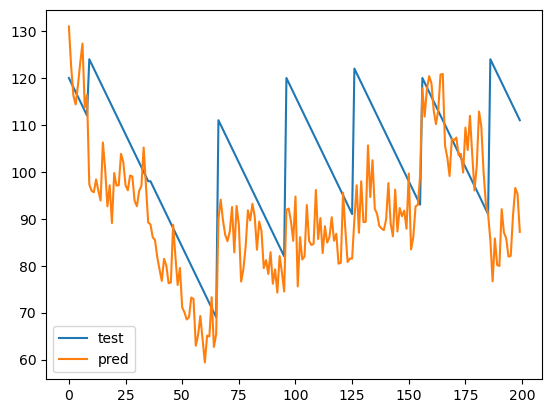

In [25]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

X_last_n, y_last_n, bunk = get_last_n_values(xa_test, ya_test, test_ref_A, 30)
print(X_last_n.shape)

ridgeA = linear_model.Ridge(alpha=0.01)
ridgeA.fit(xA_train_std, yA_train_std)
y_pred = y_scaler.inverse_transform(ridgeA.predict(X_last_n).reshape(-1, 1))

print(mean_squared_error(y_last_n, y_pred))

plt.plot(y_last_n[:200], label='True RUL')
plt.plot(y_pred[:200], label='Predicted RUL')
plt.legend(["test", "pred"])
plt.show()


4179.471541810583


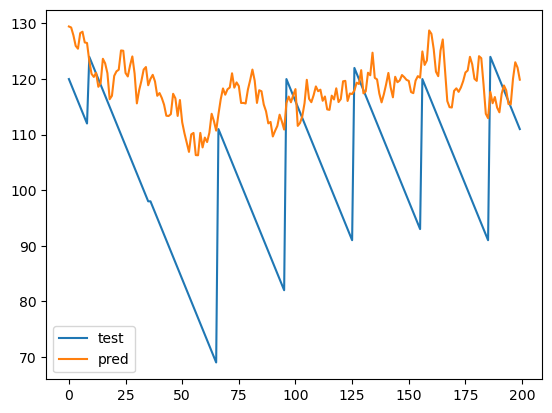

In [26]:
X_last_n, y_last_n, bunk = get_last_n_values(xb_test, yb_test, test_ref_B, 30)

ridgeB = linear_model.Ridge(alpha=0.001)
ridgeB.fit(xB_train_minMax, yB_train_minMax)
y_pred = y_scaler.inverse_transform(ridgeB.predict(X_last_n).reshape(-1, 1))

print(mean_squared_error(y_last_n, y_pred))

plt.plot(y_last_n[:200], label='True RUL')
plt.plot(y_pred[:200], label='Predicted RUL')
plt.legend(["test", "pred"])
plt.show()

(21109, 25)
1996.395814723754


/home/nolan/miniconda3/envs/ece447/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(


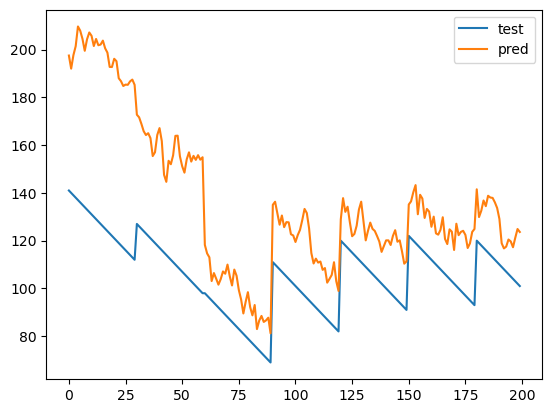

In [27]:
X_last_n, y_last_n, bunk = get_last_n_values(xc_test, yc_test, test_ref_C, 30)
print(X_last_n.shape)

ridgeC = linear_model.Ridge(alpha=0.01)
ridgeC.fit(xC_train, yC_train)
y_pred = ridgeC.predict(X_last_n).reshape(-1, 1)

print(mean_squared_error(y_last_n, y_pred))

plt.plot(y_last_n[:200], label='True RUL')
plt.plot(y_pred[:200], label='Predicted RUL')
plt.legend(["test", "pred"])
plt.show()

# Random Forest

## Hyper parameter tuning

In [28]:
from sklearn.metrics import mean_squared_error

# Load the LSTM model from the specific MLflow run
run_id = "b4e7b8d786ea45adb5962c5bd2702797"
model_uri = f"runs:/{run_id}/model"
loaded_model = mlflow.pyfunc.load_model(model_uri)

# Process data using pipeline A
X_train, X_test, y_train, y_test = preprocessing.pipeline_A(data_dict)

# Predict and evaluate RUL (Remaining Useful Life)
predictions = loaded_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"LSTM Model RMSE on Pipeline A: {rmse}")

MlflowException: Run 'b4e7b8d786ea45adb5962c5bd2702797' not found

## Final model

# XGBoost

## Hyper parameter tuning

*   After around 150 n_estimators, there is minimal change in the mse (used to as the cost function for optuna) so it more efficient to truncate there.
*   




## Final model